In [146]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix


In [147]:
df = pd.read_csv('datasets/Dataset_Reponse_Marketing.csv')

print(df.head())
print(df.info())

   Age   Sexe  Revenu_annuel  Temps_passe_sur_site  Achats_en_ligne  \
0   22  Homme          40124             16.518974                9   
1   32  Femme          26307             21.973535                8   
2   28  Femme          30040             26.762915                9   
3   16  Femme          15843             29.046008                9   
4   45  Homme          20225             21.479944                5   

   Reponse_campagne  
0                 1  
1                 1  
2                 1  
3                 0  
4                 0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   2400 non-null   int64  
 1   Sexe                  2400 non-null   object 
 2   Revenu_annuel         2400 non-null   int64  
 3   Temps_passe_sur_site  2400 non-null   float64
 4   Achats_en_ligne       24

In [148]:
df['Sexe'] = df['Sexe'].map({'Homme': 0, 'Femme': 1})

# Séparation des features et de la cible
X = df.drop(columns='Reponse_campagne')
y = df['Reponse_campagne']

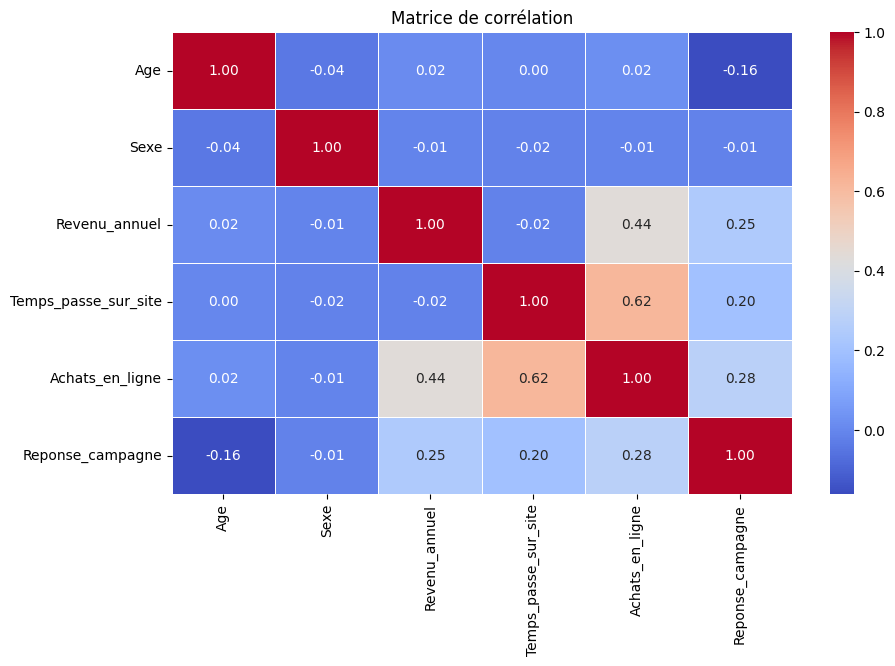

In [149]:
# Matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Affichage heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

In [150]:
# Split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation uniquement après split
features_to_scale = ['Age', 'Revenu_annuel', 'Temps_passe_sur_site', 'Achats_en_ligne']
scaler = StandardScaler()
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])


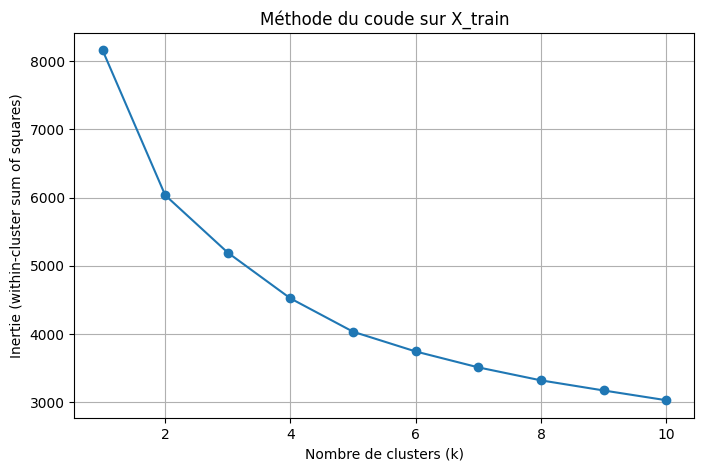

In [151]:
# Elbow method : inertie pour différents k
inertie = []
k_range = range(1, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_train)
    inertie.append(kmeans.inertia_)

# Affichage de la courbe du coude
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertie, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (within-cluster sum of squares)")
plt.title("Méthode du coude sur X_train")
plt.grid(True)
plt.show()

In [152]:
# ----- K-Means avec k=3 -----
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_train)

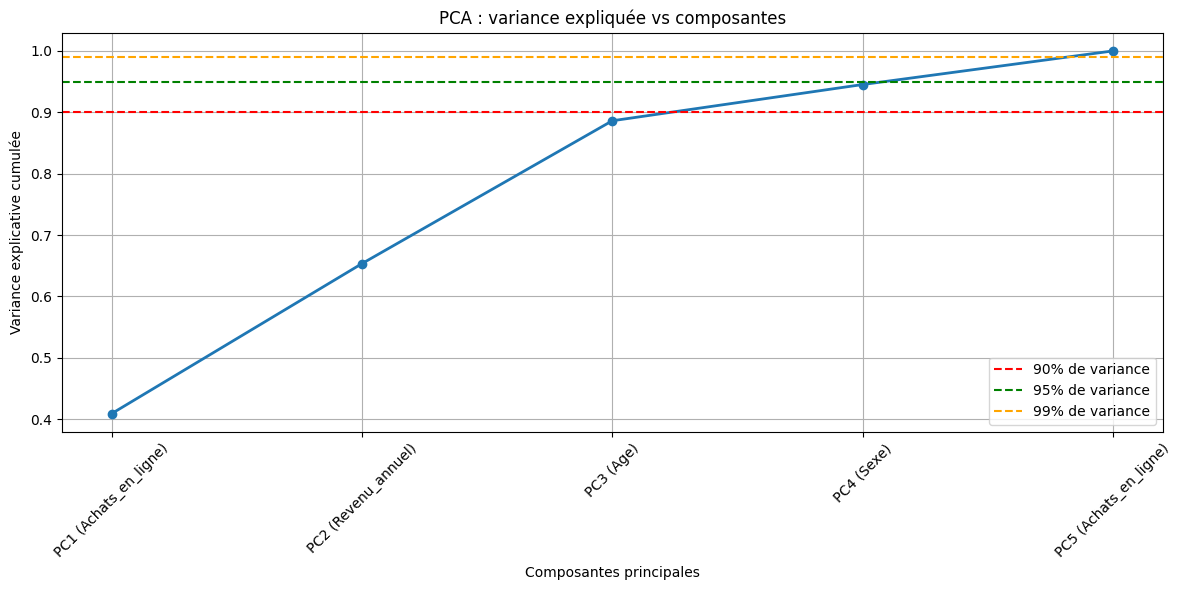

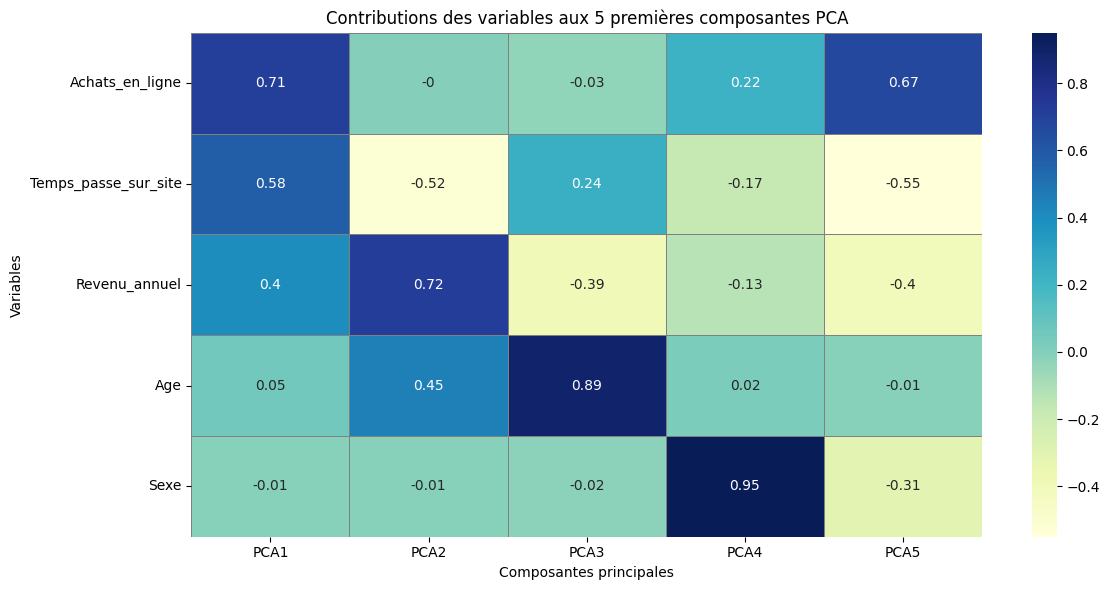

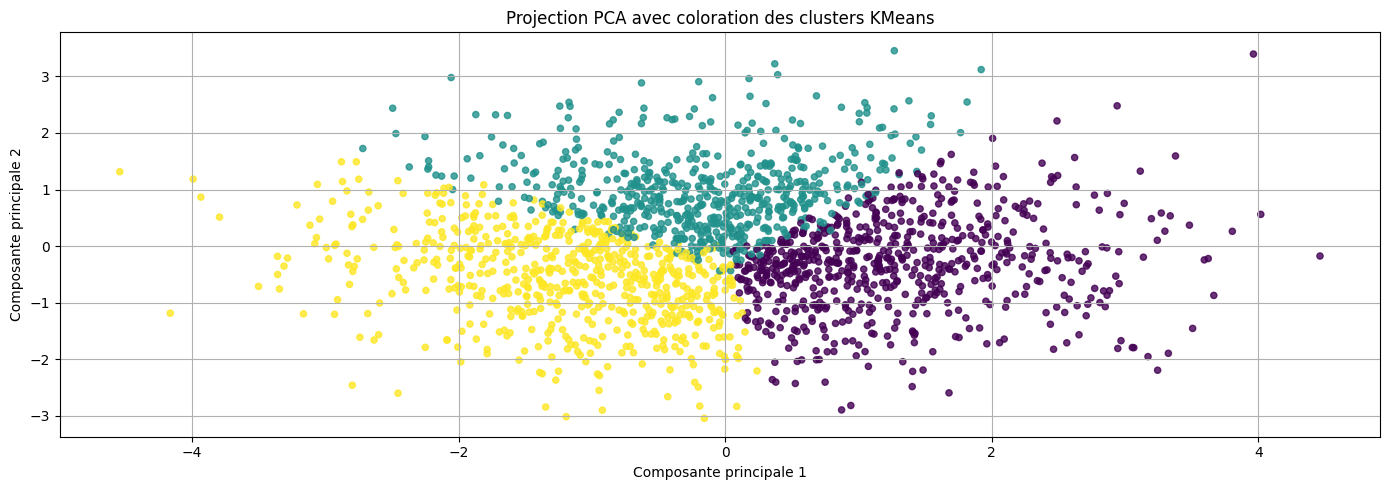

Matrice de passage (clusters vs réponse réelle) :

Vraie_classe    0    1
Cluster               
0             232  444
1             278  323
2             400  243


In [153]:
# ----- PCA -----
pca = PCA()
X_pca = pca.fit_transform(X_train)

# Variance expliquée cumulée
explained_variance_cumsum = np.cumsum(pca.explained_variance_ratio_)

# Index de la feature ayant le poids max absolu pour chaque PC
dominant_features_idx = np.abs(pca.components_).argmax(axis=1)
dominant_features = X_train.columns[dominant_features_idx]  # si X est un DataFrame

x_labels = [f"PC{i+1} ({feat})" for i, feat in enumerate(dominant_features)]

plt.figure(figsize=(12, 6))
plt.plot(explained_variance_cumsum, marker='o', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label="90% de variance")
plt.axhline(y=0.95, color='g', linestyle='--', label="95% de variance")
plt.axhline(y=0.99, color='orange', linestyle='--', label="99% de variance")
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45)
plt.xlabel("Composantes principales")
plt.ylabel("Variance explicative cumulée")
plt.title("PCA : variance expliquée vs composantes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Création du DataFrame des charges 
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=X_train.columns
)

# Tri facultatif des features par importance absolue sur la 1ère composante
pca_sorted = pca_loadings.copy()
pca_sorted['|PCA1|'] = pca_sorted['PCA1'].abs()
pca_sorted = pca_sorted.sort_values(by='|PCA1|', ascending=False).drop(columns='|PCA1|')

# Affichage sous forme de heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pca_sorted.iloc[:, :5].round(2), annot=True, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Contributions des variables aux 5 premières composantes PCA")
plt.xlabel("Composantes principales")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# ----- Visualisation des clusters -----
plt.figure(figsize=(14, 5))
plt.scatter(
    X_pca[:, 0],  # PC1
    X_pca[:, 1],  # PC2
    c=clusters,   # couleur par cluster
    cmap='viridis',  # ou 'tab10', 'Set1'...
    s=20,
    alpha=0.8
)
plt.title("Projection PCA avec coloration des clusters KMeans")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----- Matrice de passage -----
df_clusters = pd.DataFrame({'Cluster': clusters, 'Vraie_classe': y_train.reset_index(drop=True)})
matrice_passage = pd.crosstab(df_clusters['Cluster'], df_clusters['Vraie_classe'])
print("Matrice de passage (clusters vs réponse réelle) :\n")
print(matrice_passage)

Variance expliquée cumulée : 

 - Les 3 premières composantes principales (Achats en ligne, Revenu annuel, Âge) expliquent près de 90% de la variance.

 - Il faut 4 composantes pour dépasser 95% de la variance cumulée.

 - La 5e composante apporte très peu d’information supplémentaire.

Projection PCA avec clusters : 

PCA1 : 
PCA2 : Les clients avec un fort revenu passent moins de temps sur le site. Peut-être qu’ils savent ce qu’ils veulent et achètent rapidement.
PCA3 : 
PCA4 : 
PCA5 : 

On peut distinguer 3 profils differents : 

Jaune : achat en ligne élevé, navigation fréquente
Violet : peu engagé en ligne
Bleu : comportement digital présent mais moins extrême

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres trouvés :
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Meilleur score F1 (cross-validation) : 0.7185

Rapport de classification :

              precision    recall  f1-score   support

           0       0.70      0.59      0.64       227
           1       0.68      0.78      0.72       253

    accuracy                           0.69       480
   macro avg       0.69      0.68      0.68       480
weighted avg       0.69      0.69      0.68       480



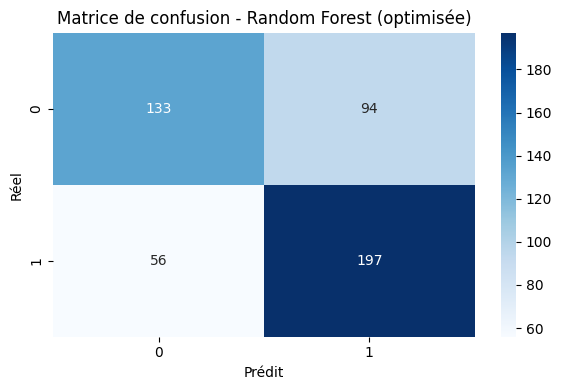

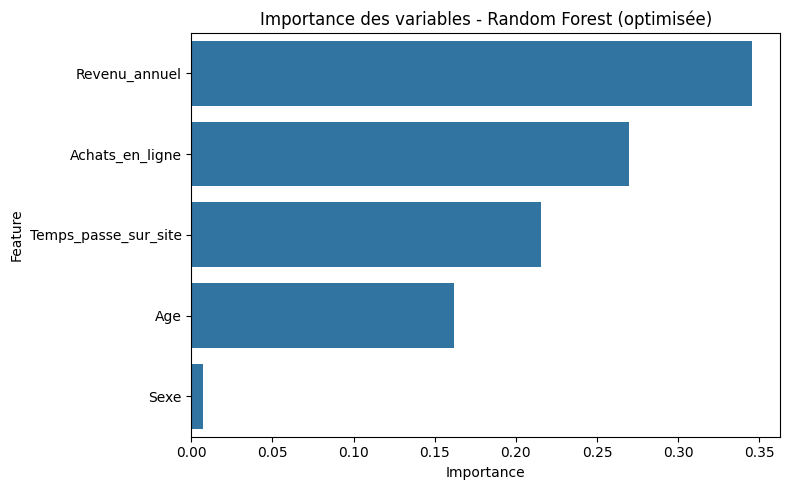

In [156]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entraînement avec GridSearch
grid_search_rf.fit(X_train, y_train)

# Récupération du meilleur modèle
rf = grid_search_rf.best_estimator_

# Évaluation du modèle
print("Meilleurs hyperparamètres trouvés :")
print(grid_search_rf.best_params_)
print(f"Meilleur score F1 (cross-validation) : {grid_search_rf.best_score_:.4f}")

# Prédictions sur le test set
y_pred = rf.predict(X_test)

# Rapport de classification
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Random Forest (optimisée)")
plt.tight_layout()
plt.show()

# Importance des variables triée
importances = rf.feature_importances_
features = X_train.columns
sorted_idx = importances.argsort()[::-1]
sorted_features = features[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(8, 5))
sns.barplot(x=sorted_importances, y=sorted_features)
plt.title("Importance des variables - Random Forest (optimisée)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Meilleurs hyperparamètres :
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}

Score F1 (cross-validation) : 0.7116

Rapport de classification (XGBoost optimisé) :
              precision    recall  f1-score   support

           0       0.70      0.59      0.64       227
           1       0.68      0.77      0.72       253

    accuracy                           0.69       480
   macro avg       0.69      0.68      0.68       480
weighted avg       0.69      0.69      0.68       480



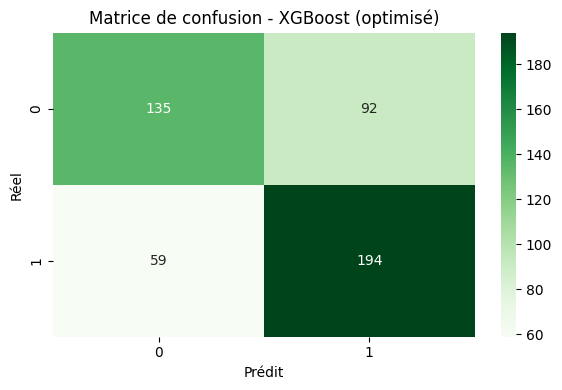

<Figure size 800x500 with 0 Axes>

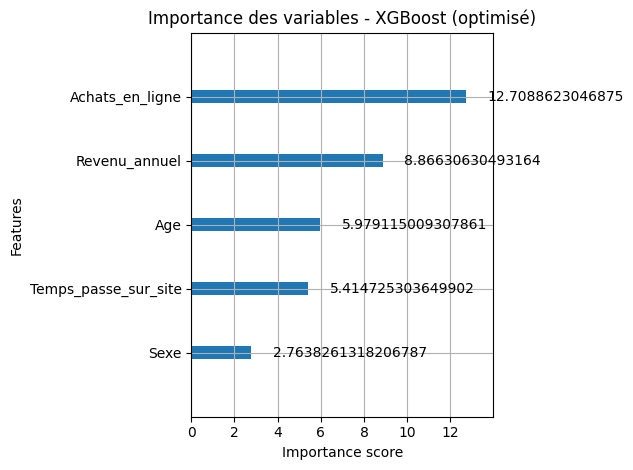

In [157]:
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le modèle de base
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1  # pour paralléliser aussi le modèle lui-même
)

# Grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Entraînement
grid_search.fit(X_train, y_train)

# Résultats
print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)
print(f"\nScore F1 (cross-validation) : {grid_search.best_score_:.4f}")

# Meilleur modèle
best_model = grid_search.best_estimator_

# Prédictions
y_pred_xgb = best_model.predict(X_test)

# Rapport de classification
print("\nRapport de classification (XGBoost optimisé) :")
print(classification_report(y_test, y_pred_xgb))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - XGBoost (optimisé)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

# Importance des variables (gain)
plt.figure(figsize=(8, 5))
plot_importance(
    best_model,
    max_num_features=10,
    importance_type='gain',
    title="Importance des variables - XGBoost (optimisé)",
    show_values=True
)
plt.tight_layout()
plt.show()
